# CURBD results across sessions and mice
## before/after perturbation change & peak-to-baseline ratio

#### Imports

In [1]:
import sys
import os
import importlib
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import find_peaks
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pylab

# pyaldata
sys.path.append("/home/zms24/Desktop") 
import PyalData.pyaldata as pyal # type:ignore

# tools functions
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from tools.curbd import curbd
from tools.dsp.preprocessing import preprocess
from tools.rnn_and_curbd import rnn as rnnz
from tools.rnn_and_curbd import plotting as pltz
from tools.rnn_and_curbd import model_analysis as analyz
from tools.rnn_and_curbd import curbd as curbdz

# Reload modules
importlib.reload(rnnz)
importlib.reload(pltz)
importlib.reload(analyz)
importlib.reload(curbdz)

np.random.seed(44)

#### Colour palette

In [2]:
curbd_colors = {'M1': "#3681D2", 'SSp': '#f4a261', 'CP': "#8ed74d", 'VAL': '#e76f51'}
model_color = '#00ff7f'
exp_color = '#232333'
trial_color = '#98fb98'
top_sol_color = "#ed6bbe"
bottom_sol_color = "#b66cea"
color_palette = {'curbd_colors': curbd_colors, 
                 'model_color': model_color, 
                 'exp_color': exp_color,
                 'trial_color': trial_color,
                 'top_sol_color': top_sol_color,
                 'bottom_sol_color': bottom_sol_color
                 }

#### Importing data from all sessions for each mouse

### M044

In [3]:
filename = 'rnn_model_M044_2024_12_04_09_30.mat'
path = os.path.join("/home/zms24/Desktop/rnn_models/", filename)

data = loadmat(path, simplify_cells=True)
rnn_model = data['rnn_model']

In [4]:
pyal_dict_44_0 = rnnz.process_pyal_M044_files("M044_2024_12_04_09_30_pyaldata.mat", rnn_model)

field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field all_KSLabel could not be converted to int.


/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(


Combined every 3 bins
Resulting all_spikes ephys data shape is (NxT): (474, 133)
Trial length: 133


### M061

In [5]:
fname0 = 'rnn_model_M061_2025_03_04_10_00.mat'
fname1 = 'rnn_model_M061_2025_03_06_14_00.mat'
path0 = os.path.join("/home/zms24/Desktop/rnn_models/", fname0)
path1 = os.path.join("/home/zms24/Desktop/rnn_models/", fname1)

data0 = loadmat(path0, simplify_cells=True)
data1 = loadmat(path1, simplify_cells=True)
rnn_model0 = data0['rnn_model']
rnn_model1 = data1['rnn_model']

In [6]:
pyal_dict_61_0 = rnnz.process_pyal_M061_M062_files(fname0, rnn_model0)
pyal_dict_61_1 = rnnz.process_pyal_M061_M062_files(fname1, rnn_model1)

field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field SSp_ul_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field idx_motion could not be converted to int.
array field SSp_ul_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field Thal_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to 

/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(


Combined every 3 bins
Resulting SSp_ul_spikes ephys data shape is (NxT): (59, 200)
Resulting Thal_spikes ephys data shape is (NxT): (240, 200)
Resulting MOp_spikes ephys data shape is (NxT): (206, 200)
Resulting CP_spikes ephys data shape is (NxT): (356, 200)
Trial length: 200
field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field GPe_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converte

/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of SSp_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of SSp_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108

Combined every 3 bins
Resulting SSp_spikes ephys data shape is (NxT): (69, 200)
Resulting VAL_spikes ephys data shape is (NxT): (168, 200)
Resulting MOp_spikes ephys data shape is (NxT): (178, 200)
Resulting CP_spikes ephys data shape is (NxT): (172, 200)
Resulting GPe_spikes ephys data shape is (NxT): (120, 200)
Trial length: 200


### M062

In [7]:
fname2 = 'rnn_model_M062_2025_03_19_14_00.mat'
fname3 = 'rnn_model_M062_2025_03_20_14_00.mat'
fname4 = 'rnn_model_M062_2025_03_21_14_00.mat'
path2 = os.path.join("/home/zms24/Desktop/rnn_models/", fname2)
path3 = os.path.join("/home/zms24/Desktop/rnn_models/", fname3)
path4 = os.path.join("/home/zms24/Desktop/rnn_models/", fname4)

data2 = loadmat(path2, simplify_cells=True)
data3 = loadmat(path3, simplify_cells=True)
data4 = loadmat(path4, simplify_cells=True)
rnn_model2 = data2['rnn_model']
rnn_model3 = data3['rnn_model']
rnn_model4 = data4['rnn_model']

In [8]:
pyal_dict_62_0 = rnnz.process_pyal_M061_M062_files(fname2, rnn_model2)
pyal_dict_62_1 = rnnz.process_pyal_M061_M062_files(fname3, rnn_model3)
pyal_dict_62_2 = rnnz.process_pyal_M061_M062_files(fname4, rnn_model4)

array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field all_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field all_KSLabel could not be converted to i

/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.86149584487535% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108

Combined every 3 bins
Resulting VAL_spikes ephys data shape is (NxT): (198, 200)
Resulting SSp_spikes ephys data shape is (NxT): (95, 200)
Resulting CP_spikes ephys data shape is (NxT): (307, 200)
Resulting MOp_spikes ephys data shape is (NxT): (210, 200)
Trial length: 200
field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
field values_Sol_direction could not be converted

/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85955056179775% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108

Combined every 3 bins
Resulting VAL_spikes ephys data shape is (NxT): (155, 200)
Resulting SSp_spikes ephys data shape is (NxT): (118, 200)
Resulting MOp_spikes ephys data shape is (NxT): (163, 200)
Resulting CP_spikes ephys data shape is (NxT): (356, 200)
Trial length: 200
field values_before_camera_trigger could not be converted to int.
field idx_before_camera_trigger could not be converted to int.
array field VAL_KSLabel could not be converted to int.
array field SSp_KSLabel could not be converted to int.
array field all_KSLabel could not be converted to int.
array field CP_KSLabel could not be converted to int.
array field MOp_KSLabel could not be converted to int.
field values_Sol_direction could not be converted to int.
field idx_Sol_direction could not be converted to int.
field values_Sol_duration could not be converted to int.
field idx_Sol_duration could not be converted to int.
field idx_sol_on could not be converted to int.
array field VAL_KSLabel could not be converted to 

/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.85875706214689% of trials
  warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108: UserWarning: Assuming spikes are actually spikes and dividing by bin size.
  utils.warnings.warn(
/home/zms24/Desktop/PyalData/pyaldata/firing_rates.py:108

Combined every 3 bins
Resulting VAL_spikes ephys data shape is (NxT): (122, 200)
Resulting SSp_spikes ephys data shape is (NxT): (66, 200)
Resulting CP_spikes ephys data shape is (NxT): (280, 200)
Resulting MOp_spikes ephys data shape is (NxT): (179, 200)
Trial length: 200


## CURBD

In [9]:
def curbd_for_all_models(models, pyal_dicts, labels):
    curbd_data = {}
    for i in range(len(models)):
        rnn_model = models[i]
        pyal_dict = pyal_dicts[i]
        label = labels[i]
        curbd_arr, curbd_labels = curbd.computeCURBD(rnn_model)
        n_regions = curbd_arr.shape[0]
        currents, current_labels = curbdz.format_curbd_output(curbd_arr, curbd_labels, n_regions, pyal_dict['reset_points'])

        curbd_data[label] = {"curbd_arr": curbd_arr,
                        "curbd_labels": curbd_labels,
                        "currents": currents,
                        "current_labels": current_labels,
                        "n_regions": n_regions,
                        "pyal_dict": pyal_dict,
                        "rnn_model": rnn_model}
    return curbd_data

In [10]:
models = [rnn_model, rnn_model0, rnn_model1, rnn_model2, rnn_model3, rnn_model4]
pyal_dicts = [pyal_dict_44_0, pyal_dict_61_0, pyal_dict_61_1, pyal_dict_62_0, pyal_dict_62_1, pyal_dict_62_2]
labels = ["M044_0", "M061_0", "M061_1", "M062_0", "M062_1", "M062_2"]

In [11]:
curbd_data = curbd_for_all_models(models, pyal_dicts, labels)

### Example currents

### Current change before/after perturbation

In [12]:
def perturb_current_change(curbd_data):
    all_change_df = []

    for label, data in curbd_data.items():
        change_df = compute_curr_change_across_perturb(
            data['currents'],
            data['current_labels'],
            data['pyal_dict']['perturbation_time_sec'],
            data['rnn_model']['dtData'],
            data['rnn_model']['params']['dtFactor']
        )
        change_df["model_id"] = label

        # Split current_label into source and target
        split_labels = change_df["current_label"].str.split(" to ", expand=True)
        split_mouse = change_df["model_id"].str.split("_", expand=True)
        change_df = change_df.drop(columns=['current_label', "model_id"])
        change_df["source"] = split_labels[0]
        change_df["target"] = split_labels[1]
        change_df["mouse"] = split_mouse[0]

        region_map = {
            "M1": "MOp",
            "Dls": "CP",
            "Thal": "VAL"
        }

        # Apply the mapping to both 'source' and 'target' columns
        change_df['source'] = change_df['source'].replace(region_map)
        change_df['target'] = change_df['target'].replace(region_map)

        all_change_df.append(change_df)

    return pd.concat(all_change_df, ignore_index=True)

def compute_curr_change_across_perturb(all_currents, all_currents_labels, perturbation_time, bin_size, dtFactor, window_size = 1):

    # window size is in seconds #
    changes = []
    time_axis = np.linspace(0, all_currents[0].shape[2] * bin_size / dtFactor, all_currents[0].shape[2])

    # Define baseline and response windows
    control_window = (perturbation_time - (window_size*2), perturbation_time - window_size)
    baseline_window = (perturbation_time - window_size, perturbation_time)
    response_window = (perturbation_time, perturbation_time + window_size)

    # Get indices for these time windows
    control_idx = np.where((time_axis >= control_window[0]) & (time_axis < control_window[1]))[0]
    baseline_idx = np.where((time_axis >= baseline_window[0]) & (time_axis < baseline_window[1]))[0]
    response_idx = np.where((time_axis >= response_window[0]) & (time_axis < response_window[1]))[0]

    for i, current_data in enumerate(all_currents):
        current_label = all_currents_labels[i]
        current_data = np.array(current_data) # shape: (174, 11, 400) (neurons, trial_types, time)

        # Average across neurons and trials
        mean_current = np.mean(current_data, axis=(0, 1))

        # Baseline and peak
        control_mean = np.mean(np.abs(mean_current[control_idx]))
        baseline_mean = np.mean(np.abs(mean_current[baseline_idx]))
        response_mean = np.mean(np.abs(mean_current[response_idx]))

        control_change_value = np.abs(control_mean - baseline_mean)
        change_value = np.abs(baseline_mean - response_mean)

        changes.append({
            "current_label": current_label,
            "before_perturb": baseline_mean,
            "after_perturb": response_mean,
            "current_change": change_value,
            "control_current": control_change_value
        })

    df_change = pd.DataFrame(changes)
    return df_change

In [13]:
current_change_df = perturb_current_change(curbd_data)

In [14]:
current_change_df.head()

,before_perturb,after_perturb,current_change,control_current,source,target,mouse
0,0.190547,0.253567,0.063020,0.006061,MOp,MOp,M044
1,0.257786,0.328495,0.070709,0.009675,CP,MOp,M044
2,0.158847,0.211070,0.052223,0.003893,MOp,CP,M044
3,0.251429,0.310090,0.058661,0.007716,CP,CP,M044
4,0.612643,0.600401,0.012241,0.006974,MOp,MOp,M061


#### stat analysis - norm, t-test or other depending on norm results

H0:The magnitude of change in current after the perturbation is not significantly different from the change observed before the perturbation.


H1:The magnitude of change in current after the perturbation is significantly different from the change observed before the perturbation.

In [15]:
alpha = 0.05

# Normality tests
# Shapiro-Wilk test for normality
shapiro_before, pval_before = stats.shapiro(current_change_df['control_current'])
shapiro_after, pval_after = stats.shapiro(current_change_df['current_change'])

if pval_before > alpha and pval_after > alpha:
    result1 = 'Normal'
else:
    result1 = 'NOT Normal'
print(f'Shapiro-Wilk: {result1:>19s}')

# D'Agostino and Pearson's test for normality
dagostino_before, pval_before = stats.normaltest(current_change_df['control_current'])
dagostino_after, pval_after = stats.normaltest(current_change_df['current_change'])

if pval_before > alpha and pval_after > alpha:
    result2 = 'Normal'
else:
    result2 = 'NOT Normal'
print(f"\nD'Agostino and Pearson's Normality Test Results: {result2:>19s}")

# As its not normal therefore -> Non-parametric test (Wilcoxon Signed-Rank Test)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(current_change_df['control_current'], current_change_df['current_change'])
print(f"\nWilcoxon Signed-Rank Test Result: Stat: {wilcoxon_stat}, p-value: {wilcoxon_p}")
if wilcoxon_p < alpha:
    print("RESULT - Significant difference, reject H0, accept H1")
else:
    print("RESULT - NO significant difference, reject H1, accept H0")


Shapiro-Wilk:          NOT Normal

D'Agostino and Pearson's Normality Test Results:          NOT Normal

Wilcoxon Signed-Rank Test Result: Stat: 66.0, p-value: 1.7695023902864388e-14
RESULT - Significant difference, reject H0, accept H1


#### plotting the results

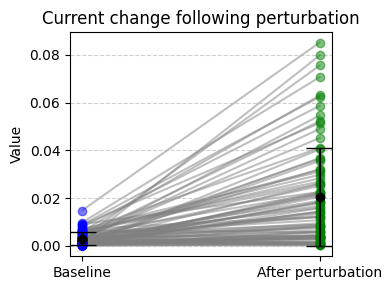

In [16]:
# Create the data
control = current_change_df['control_current'].values
change = current_change_df['current_change'].values

# Number of pairs
n = len(control)

# X positions for bar groups
x_positions = [0, 1]

# Create the figure
plt.figure(figsize=(4, 3))

# Plot individual lines connecting pairs
for i in range(n):
    plt.plot(x_positions, [control[i], change[i]], color='gray', alpha=0.5, zorder=1)

# Plot individual points
plt.scatter(np.repeat(x_positions[0], n), control, color='blue', label='Baseline', zorder=2, alpha = 0.5)
plt.scatter(np.repeat(x_positions[1], n), change, color='green', label='After perturbation', zorder=2, alpha = 0.5)

# Plot means with error bars (std)
mean_control = np.mean(control)
mean_change = np.mean(change)
std_control = np.std(control)
std_change = np.std(change)

plt.errorbar(x_positions[0], mean_control, yerr=std_control, fmt='o', color='black', capsize=10)
plt.errorbar(x_positions[1], mean_change, yerr=std_change, fmt='o', color='black', capsize=10)

# Aesthetic adjustments
plt.xticks(x_positions, ['Baseline', 'After perturbation'])
plt.ylabel('Value')
plt.title('Current change following perturbation')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

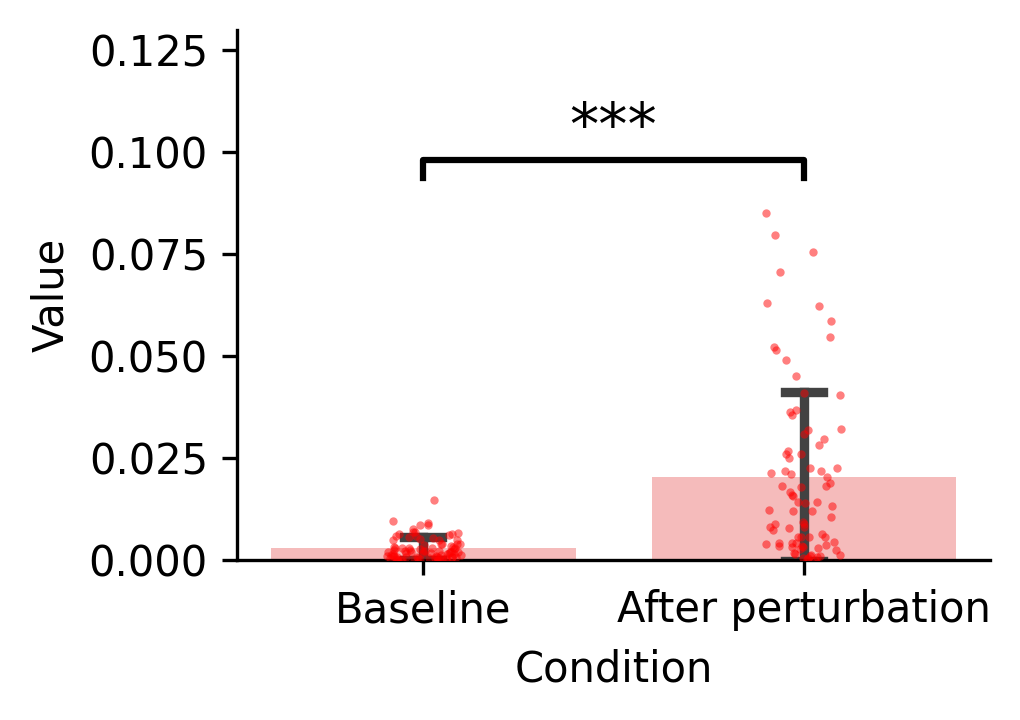

In [17]:
# Melt the dataframe into long format for easier plotting
plot_df = pd.melt(current_change_df, value_vars=['control_current', 'current_change'],
                  var_name='Condition', value_name='Value')

# Set the figure size and style
plt.figure(figsize=(3.5, 2.5),dpi=300)

# Create a bar plot with individual data points overlaid
sns.barplot(data=plot_df, x='Condition', y='Value', errorbar='sd', capsize=0.1, color='red', alpha =0.3)
sns.stripplot(data=plot_df, x='Condition', y='Value', color='red', alpha =0.5, size=2, jitter=True)

# Add significance bar
y_max = max(np.max(control), np.max(change))
bar_height = y_max + 0.1 * y_max  # height of the bar
bar_buffer = 0.05 * y_max         # space above the highest point

# Draw the line
plt.plot([x_positions[0], x_positions[0], x_positions[1], x_positions[1]],
         [bar_height, bar_height + bar_buffer, bar_height + bar_buffer, bar_height],
         color='black')

# Add p-value or asterisk
p_val = 1.77e-14  # your Wilcoxon p-value
if p_val < 0.001:
    significance = '***'
elif p_val < 0.01:
    significance = '**'
elif p_val < 0.05:
    significance = '*'
else:
    significance = 'ns'

plt.text(0.5, bar_height + bar_buffer + 0.01 * y_max, significance,
         ha='center', va='bottom', fontsize=14)

# Title and labels
x_positions = [0, 1]
# plt.title('Comparison of Control vs Current Change')
plt.xticks([0, 1], ['Baseline', 'After perturbation'])
plt.ylabel('Value')
plt.xlabel('Condition')
plt.ylim(0, 0.13)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Show plot
plt.tight_layout()
plt.show()

### Peak-to-baseline ratio

In [18]:
def compute_peak_to_baseline_ratios(all_currents, all_currents_labels, perturbation_time, bin_size, dtFactor):
    ratios = []
    time_axis = np.linspace(0, all_currents[0].shape[2] * bin_size / dtFactor, all_currents[0].shape[2])

    # Define baseline and response windows
    baseline_window = (perturbation_time - 0.5, perturbation_time)
    response_window = (perturbation_time, perturbation_time + 0.5)

    # Get indices for these time windows
    baseline_idx = np.where((time_axis >= baseline_window[0]) & (time_axis < baseline_window[1]))[0]
    response_idx = np.where((time_axis >= response_window[0]) & (time_axis < response_window[1]))[0]

    for i, current_data in enumerate(all_currents):
        current_label = all_currents_labels[i]
        current_data = np.array(current_data) # shape: (174, 11, 400) (neurons, trial_types, time)
 
        # Average across conditions and trials
        mean_current = np.mean(current_data, axis=(0, 1))

        # Baseline and peak
        baseline_mean = np.mean(np.abs(mean_current[baseline_idx]))
        response_peak = np.max(np.abs(mean_current[response_idx]))

        ratio = response_peak / baseline_mean if baseline_mean != 0 else np.nan

        ratios.append({
            "current_label": current_label,
            "baseline": baseline_mean,
            "peak": response_peak,
            "peak_to_baseline_ratio": ratio
        })

    df_ratios = pd.DataFrame(ratios)
    return df_ratios

def peak_to_baseline(curbd_data):
    all_ratio_df = []

    for label, data in curbd_data.items():
        ratio_df = compute_peak_to_baseline_ratios(
            data['currents'],
            data['current_labels'],
            data['pyal_dict']['perturbation_time_sec'],
            data['rnn_model']['dtData'],
            data['rnn_model']['params']['dtFactor']
        )
        ratio_df["model_id"] = label

        # Split current_label into source and target
        split_labels = ratio_df["current_label"].str.split(" to ", expand=True)
        split_mouse = ratio_df["model_id"].str.split("_", expand=True)
        ratio_df = ratio_df.drop(columns=['current_label', "model_id"])
        ratio_df["source"] = split_labels[0]
        ratio_df["target"] = split_labels[1]
        ratio_df["mouse"] = split_mouse[0]

        region_map = {
            "M1": "MOp",
            "Dls": "CP",
            "Thal": "VAL"
        }

        # Apply the mapping to both 'source' and 'target' columns
        ratio_df['source'] = ratio_df['source'].replace(region_map)
        ratio_df['target'] = ratio_df['target'].replace(region_map)

        all_ratio_df.append(ratio_df)

    return pd.concat(all_ratio_df, ignore_index=True)

In [19]:
baseline_peak_df = peak_to_baseline(curbd_data)

In [20]:
baseline_peak_df.head(10)

,baseline,peak,peak_to_baseline_ratio,source,target,mouse
0,0.192075,0.336219,1.750460,MOp,MOp,M044
1,0.261037,0.429602,1.645753,CP,MOp,M044
2,0.160277,0.284714,1.776384,MOp,CP,M044
3,0.255208,0.395218,1.548608,CP,CP,M044
4,0.608718,0.646239,1.061641,MOp,MOp,M061
5,0.228696,0.267545,1.169874,SSp,MOp,M061
6,0.550689,0.661225,1.200724,CP,MOp,M061
7,0.416212,0.442010,1.061983,VAL,MOp,M061
8,0.575267,0.601306,1.045264,MOp,SSp,M061
9,0.162391,0.183382,1.129260,SSp,SSp,M061


In [21]:
def plot_ratios_by_source(baseline_peak_df):
    source_regions = sorted(baseline_peak_df['source'].unique())[:4]

    # Define colormaps for brain areas
    area_cmaps = {
        'MOp': plt.cm.Blues,
        'SSp': plt.cm.YlOrBr,
        'CP': plt.cm.YlGn,
        'VAL': plt.cm.Reds,
        'all': plt.cm.Greys
    }

    # Define intensity for each mouse
    mouse_shades = {'M044': 0.6, 'M061': 0.6, 'M062': 0.6}

    fig, axes = plt.subplots(2, 2, figsize=(6, 4), dpi = 300)
    axes = axes.flatten()

    for i, source in enumerate(source_regions):
        ax = axes[i]
        data = baseline_peak_df[baseline_peak_df['source'] == source]

        for mouse in data['mouse'].unique():
            mouse_data = data[data['mouse'] == mouse]

            mouse_id = mouse.split('_')[0]  # extract 'M044' from 'M044_0'
            cmap = area_cmaps.get(source, plt.cm.Greys)
            shade = mouse_shades.get(mouse_id, 0.5)
            color = cmap(shade)

            ax.scatter(
                mouse_data['target'],
                mouse_data['peak_to_baseline_ratio'],
                label=mouse,
                color=color,
                alpha = 0.6,
                s=30
            )

        ax.set_title(f"{source} → Target Regions", fontsize=12)
        # ax.set_xlabel("Target Region")
        ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
        ax.tick_params(axis='x', rotation=45)
    

    # Create a legend using unique mice
    handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, title="Mouse", bbox_to_anchor=(1.02, 0.5), loc="center left")

    # fig.suptitle("Baseline-to-Peak Ratios by Source Region", fontsize=16)
    plt.ylabel("Peak-to-Baseline Ratio")
    plt.tight_layout()
    plt.show()

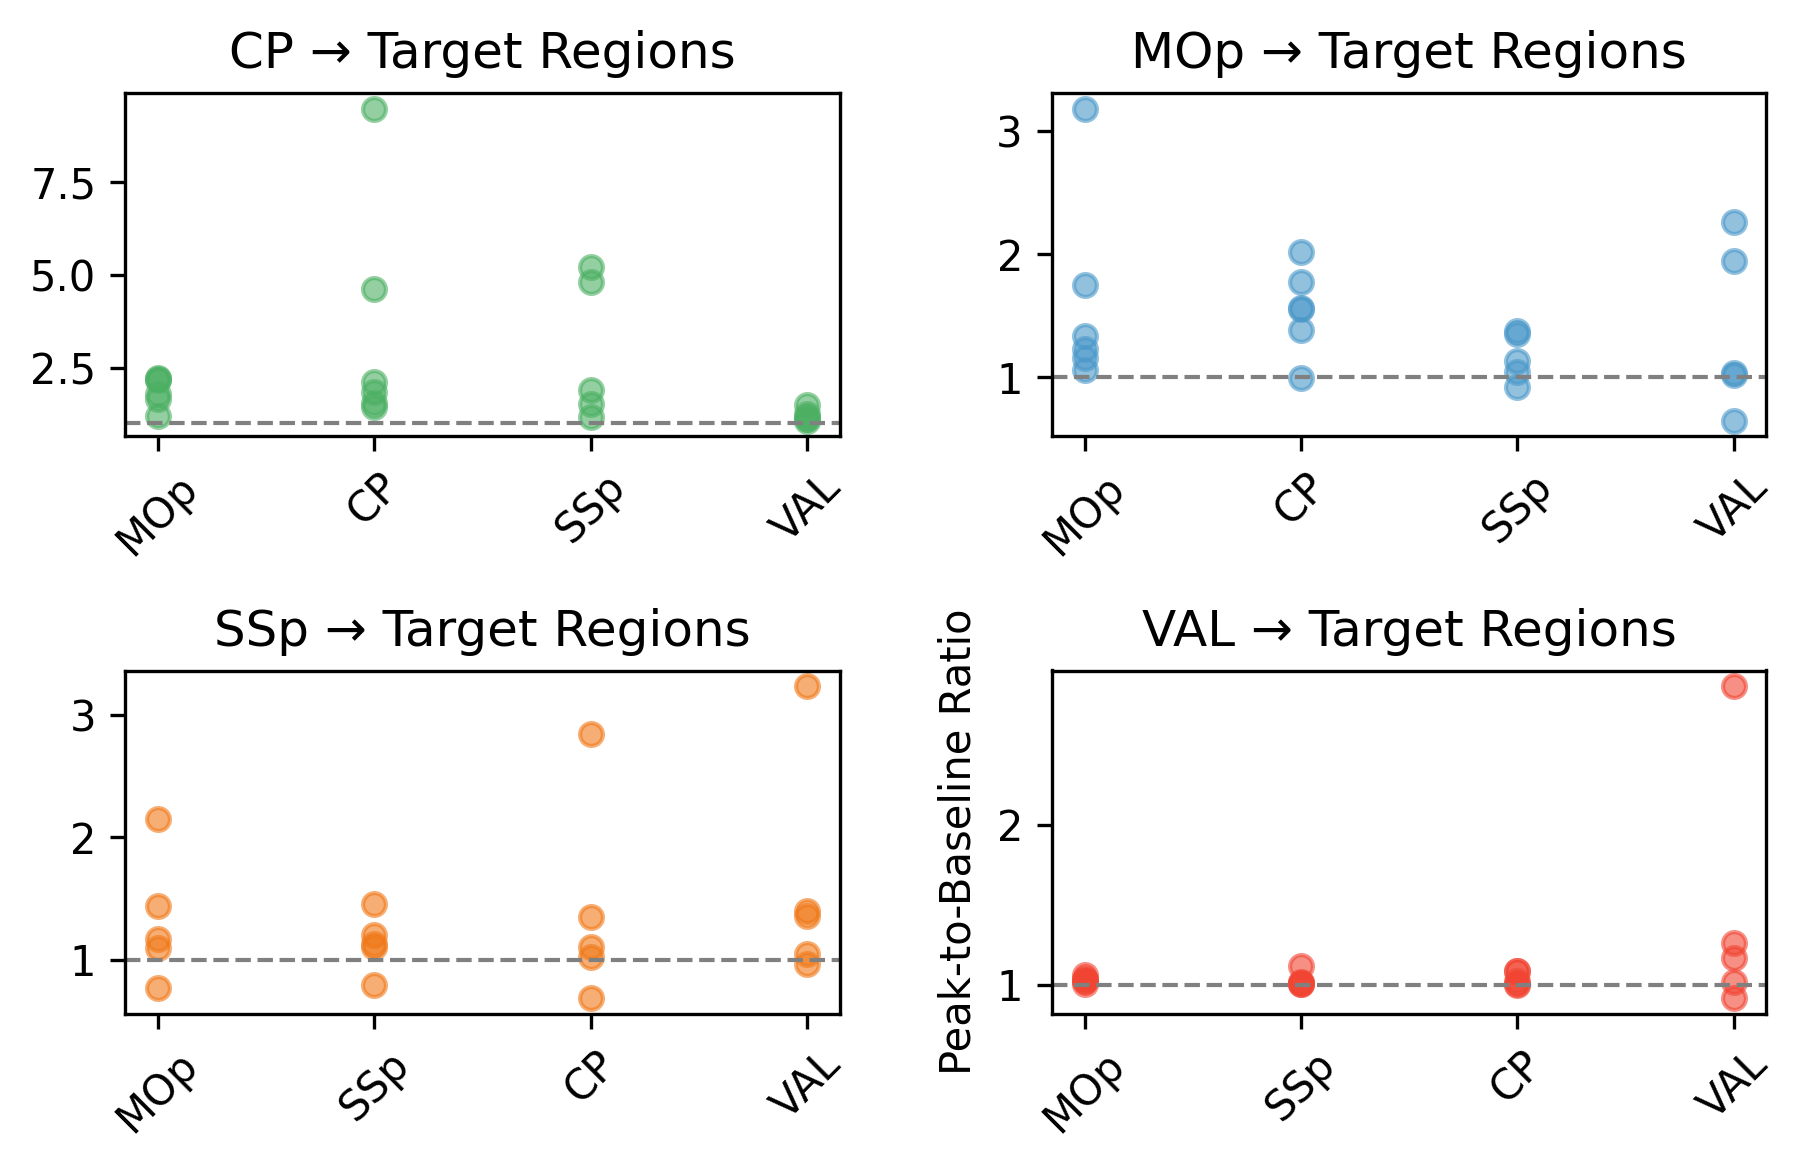

In [22]:
plot_ratios_by_source(baseline_peak_df)

### Pool the results into a bar graph (pooled by target, pooled by source)

In [23]:
def add_significance_bar(ax, x1, x2, y, h=0.01, text="*", fontsize=12):
    """Draw a significance bar between two x locations at height y"""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='k')
    ax.text((x1 + x2) * 0.5, y , text, ha='center', va='bottom', fontsize=fontsize)

def plot_bar_with_points(data, group_by='source', sig_matrix=None, alpha=0.05):
    assert group_by in ['source', 'target'], "group_by must be 'source' or 'target'"

    plt.figure(figsize=(3.5, 2.5), dpi=300)

    # Define brain area colormaps -> pick one representative color
    area_colors = {
        'MOp': "#3699D2",
        'SSp': "#ff9034",
        'CP': "#7ae56c",
        'VAL': "#e75151",
        'all': '#bbbbbb'
    }
    

    # Sort for consistent display
    ordered = sorted(data[group_by].unique())

    # Assign colors to each bar based on the brain area
    bar_colors = [area_colors.get(region, 'gray') for region in ordered]

    # Bar plot (drawn one bar per region with correct color)
    ax = sns.barplot(
        data=data,
        x=group_by,
        y='peak_to_baseline_ratio',
        estimator=np.mean,
        errorbar=('ci', 95),
        order=ordered,
        palette=bar_colors,   # 👈 use the custom colors
        capsize=0.1,
        alpha=0.6,
    )

    # Overlay individual data points with the same region colors
    for i, region in enumerate(ordered):
        region_data = data[data[group_by] == region]
        sns.stripplot(
            x=[region]*len(region_data),
            y=region_data['peak_to_baseline_ratio'],
            color=area_colors.get(region, 'gray'),
            size=3,
            jitter=True,
            alpha=0.7,
            ax=ax,
        )

    # Significance annotations
    if sig_matrix is not None:
        max_vals = data.groupby(group_by)['peak_to_baseline_ratio'].max()
        max_height = max_vals.max()
        y_base = max_height + 0.05
        h = 0.5

        for i in range(len(ordered)):
            for j in range(i+1, len(ordered)):
                region1 = ordered[i]
                region2 = ordered[j]
                p = sig_matrix.loc[region1, region2]

                if p < alpha:
                    if p < 0.001:
                        text = '***'
                    elif p < 0.01:
                        text = '**'
                    elif p < 0.05:
                        text = '*'
                    else:
                        text = 'ns'

                    add_significance_bar(ax, i, j, y_base, h=h, text=text)
                    y_base += 1.3  

    # Aesthetic tweaks
    ax.set_title(f"Peak-to-Baseline Ratios by {group_by.capitalize()} Region")
    ax.set_ylabel("Peak-to-Baseline Ratio")
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if sig_matrix is not None and not sig_matrix.empty:
        plt.ylim(0, data['peak_to_baseline_ratio'].max() + 4)
    plt.show()


In [24]:
alpha = 0.05
import scikit_posthocs as sp

def test_normality_by_group(df, group_col, value_col, alpha=0.05):
    grouped = df.groupby(group_col)[value_col]
    results = []

    for name, group in grouped:
        stat, p = stats.shapiro(group)
        normality = 'Normal' if p > alpha else 'NOT Normal'
        results.append({
            group_col: name,
            'W-statistic': stat,
            'p-value': p,
            'Result': normality
        })

    return pd.DataFrame(results).sort_values(by='p-value')

def run_kruskal(df, group_col, value_col):
    groups = [group[value_col].values for name, group in df.groupby(group_col)]
    stat, p = stats.kruskal(*groups)
    return stat, p

def run_dunn(df, group_col, value_col, p_adjust='holm'):
    return sp.posthoc_dunn(df, val_col=value_col, group_col=group_col, p_adjust=p_adjust)

In [25]:
print("Normality Test (by Source Region):")
print(test_normality_by_group(baseline_peak_df, 'source', 'peak_to_baseline_ratio', alpha))

print("\nNormality Test (by Target Region):")
print(test_normality_by_group(baseline_peak_df, 'target', 'peak_to_baseline_ratio', alpha))

print("\n!Non-parametric test needed!")

print("\nKruskal-Wallis Test (source):", run_kruskal(baseline_peak_df, 'source', 'peak_to_baseline_ratio'))
print("Kruskal-Wallis Test (target):", run_kruskal(baseline_peak_df, 'target', 'peak_to_baseline_ratio'))

print("\nDunn's Test (source):")
dunn_source = run_dunn(baseline_peak_df, 'source', 'peak_to_baseline_ratio')
print(dunn_source)

print("\nDunn's Test (target):")
dunn_target = run_dunn(baseline_peak_df, 'target', 'peak_to_baseline_ratio')
print(dunn_target)

Normality Test (by Source Region):
  source  W-statistic       p-value      Result
3    VAL     0.375636  2.854456e-08  NOT Normal
0     CP     0.645687  4.295463e-06  NOT Normal
2    SSp     0.759060  2.251357e-04  NOT Normal
1    MOp     0.879364  1.174851e-02  NOT Normal

Normality Test (by Target Region):
  target  W-statistic       p-value      Result
0     CP     0.543018  3.419494e-07  NOT Normal
2    SSp     0.534566  6.635398e-07  NOT Normal
3    VAL     0.774334  3.667633e-04  NOT Normal
1    MOp     0.851217  3.567424e-03  NOT Normal

!Non-parametric test needed!

Kruskal-Wallis Test (source): (26.29015278838807, 8.292170907812363e-06)
Kruskal-Wallis Test (target): (1.589037433155056, 0.661878054965982)

Dunn's Test (source):
           CP       MOp       SSp       VAL
CP   1.000000  0.057486  0.010681  0.000003
MOp  0.057486  1.000000  0.432636  0.022531
SSp  0.010681  0.432636  1.000000  0.105215
VAL  0.000003  0.022531  0.105215  1.000000

Dunn's Test (target):
      CP  

/tmp/ipykernel_3039422/3810450275.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


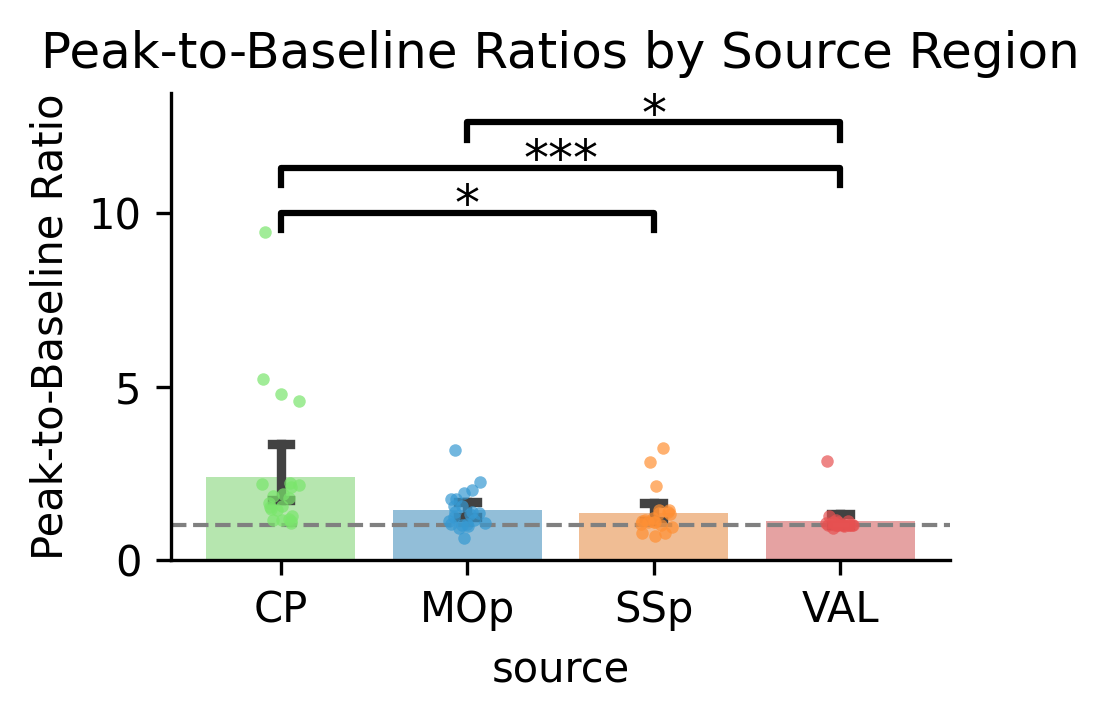

/tmp/ipykernel_3039422/3810450275.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


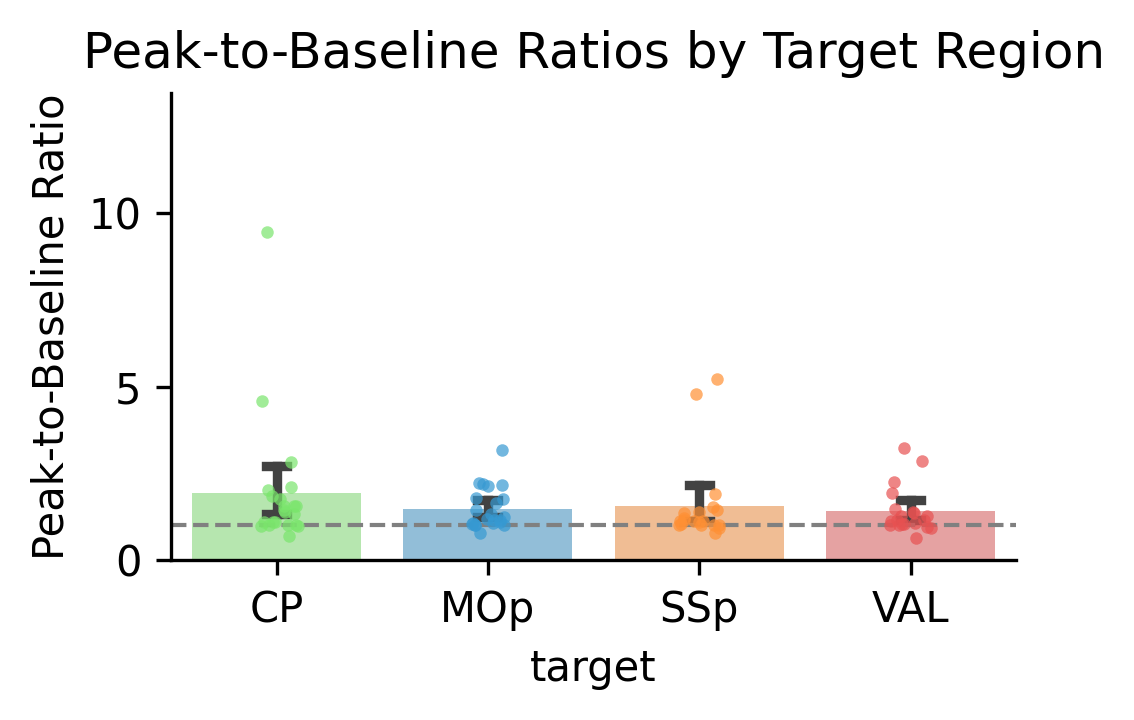

In [26]:
plot_bar_with_points(baseline_peak_df, group_by='source', sig_matrix=dunn_source, alpha=alpha)
plot_bar_with_points(baseline_peak_df, group_by='target', sig_matrix=dunn_target, alpha=alpha)

### Stats on this

In [27]:
alpha = 0.05

def test_normality_by_group(df, group_col, value_col, alpha=0.05):
    grouped = df.groupby(group_col)[value_col]
    results = []

    for name, group in grouped:
        stat, p = stats.shapiro(group)
        normality = 'Normal' if p > alpha else 'NOT Normal'
        results.append({
            group_col: name,
            'W-statistic': stat,
            'p-value': p,
            'Result': normality
        })

    return pd.DataFrame(results).sort_values(by='p-value')

In [28]:
print("Normality Test (by Source Region):")
print(test_normality_by_group(baseline_peak_df, 'source', 'peak_to_baseline_ratio', alpha))

print("\nNormality Test (by Target Region):")
print(test_normality_by_group(baseline_peak_df, 'target', 'peak_to_baseline_ratio', alpha))

Normality Test (by Source Region):
  source  W-statistic       p-value      Result
3    VAL     0.375636  2.854456e-08  NOT Normal
0     CP     0.645687  4.295463e-06  NOT Normal
2    SSp     0.759060  2.251357e-04  NOT Normal
1    MOp     0.879364  1.174851e-02  NOT Normal

Normality Test (by Target Region):
  target  W-statistic       p-value      Result
0     CP     0.543018  3.419494e-07  NOT Normal
2    SSp     0.534566  6.635398e-07  NOT Normal
3    VAL     0.774334  3.667633e-04  NOT Normal
1    MOp     0.851217  3.567424e-03  NOT Normal


We need a non-paramentric test :) 

In [29]:
def run_kruskal(df, group_col, value_col):
    groups = [group[value_col].values for name, group in df.groupby(group_col)]
    stat, p = stats.kruskal(*groups)
    return stat, p

In [30]:
print("Kruskal-Wallis Test (source):", run_kruskal(baseline_peak_df, 'source', 'peak_to_baseline_ratio'))
print("Kruskal-Wallis Test (target):", run_kruskal(baseline_peak_df, 'target', 'peak_to_baseline_ratio'))

Kruskal-Wallis Test (source): (26.29015278838807, 8.292170907812363e-06)
Kruskal-Wallis Test (target): (1.589037433155056, 0.661878054965982)


In [31]:
import scikit_posthocs as sp

def run_dunn(df, group_col, value_col, p_adjust='holm'):
    return sp.posthoc_dunn(df, val_col=value_col, group_col=group_col, p_adjust=p_adjust)

In [32]:
print("Dunn's Test (source):")
print(run_dunn(baseline_peak_df, 'source', 'peak_to_baseline_ratio'))

print("\nDunn's Test (target):")
print(run_dunn(baseline_peak_df, 'target', 'peak_to_baseline_ratio'))

Dunn's Test (source):
           CP       MOp       SSp       VAL
CP   1.000000  0.057486  0.010681  0.000003
MOp  0.057486  1.000000  0.432636  0.022531
SSp  0.010681  0.432636  1.000000  0.105215
VAL  0.000003  0.022531  0.105215  1.000000

Dunn's Test (target):
      CP  MOp  SSp  VAL
CP   1.0  1.0  1.0  1.0
MOp  1.0  1.0  1.0  1.0
SSp  1.0  1.0  1.0  1.0
VAL  1.0  1.0  1.0  1.0


### Another question, is there an order were the currents peak? One always before another one?

### lets explore that then...

In [39]:
def compute_peak_timing(all_currents, all_currents_labels, perturbation_time, bin_size, dtFactor):
    peak_times = []
    time_axis = np.linspace(0, all_currents[0].shape[2] * bin_size / dtFactor, all_currents[0].shape[2])

    # Define baseline and response windows
    response_window = (perturbation_time, perturbation_time + 1.5)

    # Get indices for these time windows
    response_idx = np.where((time_axis >= response_window[0]) & (time_axis < response_window[1]))[0]

    for i, current_data in enumerate(all_currents):
        current_label = all_currents_labels[i]
        current_data = np.array(current_data) # shape: (174, 11, 400) (neurons, trial_types, time)
 
        # Average across conditions and trials
        mean_current = np.mean(current_data, axis=(0, 1))

        # Get signal in response window
        response_signal = mean_current[response_idx]

        # Find peaks in the response window
        peaks, props = find_peaks(
            np.abs(response_signal),
            height=np.std(response_signal) * 5
        )
        print(peaks, props)

        valid_peaks = []
        valid_heights = []
        for p_idx, height in zip(peaks, props["peak_heights"]):
            absolute_peak_idx = response_idx[p_idx]
            peak_time_absolute = time_axis[absolute_peak_idx]
            if peak_time_absolute >= perturbation_time:
                valid_peaks.append(p_idx)
                valid_heights.append(height)

        if valid_peaks:
            tallest_peak_idx = valid_peaks[np.argmax(valid_heights)]
            absolute_peak_idx = response_idx[tallest_peak_idx]

            # Convert to relative time
            peak_time_absolute = time_axis[absolute_peak_idx]
            peak_time_relative = peak_time_absolute - perturbation_time

            peak_times.append({
                "current_label": current_label,
                "peak": np.max(valid_heights),
                "peak_time_after_perturb": peak_time_relative
            })

    df_times = pd.DataFrame(peak_times)
    return df_times

def peak_timing_df(curbd_data):
    all_times_df = []

    for label, data in curbd_data.items():
        peak_times_df = compute_peak_timing(
            data['currents'],
            data['current_labels'],
            data['pyal_dict']['perturbation_time_sec'],
            data['rnn_model']['dtData'],
            data['rnn_model']['params']['dtFactor']
        )
        peak_times_df["model_id"] = label

        # Split current_label into source and target
        split_labels = peak_times_df["current_label"].str.split(" to ", expand=True)
        split_mouse = peak_times_df["model_id"].str.split("_", expand=True)
        peak_times_df = peak_times_df.drop(columns=['current_label', "model_id"])
        peak_times_df["source"] = split_labels[0]
        peak_times_df["target"] = split_labels[1]
        peak_times_df["mouse"] = split_mouse[0]

        region_map = {
            "M1": "MOp",
            "Dls": "CP",
            "Thal": "VAL"
        }

        # Apply the mapping to both 'source' and 'target' columns
        peak_times_df['source'] = peak_times_df['source'].replace(region_map)
        peak_times_df['target'] = peak_times_df['target'].replace(region_map)

        all_times_df.append(peak_times_df)

    return pd.concat(all_times_df, ignore_index=True)

In [40]:
import matplotlib.colors as mcolors
def blend_colors(source_hex, target_hex, source_weight=0.6):
    """Blend two hex colors, source-dominant."""
    source_rgb = mcolors.to_rgb(source_hex)
    target_rgb = mcolors.to_rgb(target_hex)

    blended_rgb = tuple(
        source_weight * s + (1 - source_weight) * t
        for s, t in zip(source_rgb, target_rgb)
    )
    return mcolors.to_hex(blended_rgb)

def generate_directional_colors(area_colors, source_weight=0.7):
    curbd_colors = {}
    areas = [k for k in area_colors if k != 'all']  # exclude 'all'

    for source in areas:
        for target in areas:
            key = f'{source} to {target}'
            source_color = area_colors[source]
            target_color = area_colors[target]
            blended = blend_colors(source_color, target_color, source_weight)
            curbd_colors[key] = blended

    return curbd_colors

In [45]:
brain_area_colors = {
    'MOp': "#3699D2",
    'SSp': "#ff9d4d",
    'CP': "#5dd74d",
    'VAL': "#e75151",
    'all': '#bbbbbb'
}

curbd_colors = generate_directional_colors(brain_area_colors)

In [42]:
peak_timings_df = peak_timing_df(curbd_data)
peak_timings_df.head()

[19] {'peak_heights': array([0.33621925])}
[17] {'peak_heights': array([0.42960229])}
[19] {'peak_heights': array([0.28471353])}
[16] {'peak_heights': array([0.39521753])}
[24 40 57 84] {'peak_heights': array([0.64623934, 0.67286918, 0.64996522, 0.65411257])}
[12 33 52 70] {'peak_heights': array([0.26754501, 0.23439256, 0.22543113, 0.22677225])}
[15 33 55] {'peak_heights': array([0.66122499, 0.57478031, 0.55881736])}
[27 44 63 82] {'peak_heights': array([0.44200993, 0.47141147, 0.43601466, 0.44582392])}
[23 40 56 83] {'peak_heights': array([0.60130594, 0.61616105, 0.60212346, 0.60518027])}
[12 33 72] {'peak_heights': array([0.18338192, 0.16297191, 0.15892702])}
[15 34 56] {'peak_heights': array([0.77494768, 0.67679452, 0.66867116])}
[] {'peak_heights': array([], dtype=float64)}
[] {'peak_heights': array([], dtype=float64)}
[ 4 72] {'peak_heights': array([0.02781706, 0.02760099])}
[14 35 52] {'peak_heights': array([0.09804815, 0.05780604, 0.06632569])}
[27 44 65 76] {'peak_heights': arr

,peak,peak_time_after_perturb,source,target,mouse
0,0.336219,0.290677,MOp,MOp,M044
1,0.429602,0.260602,CP,MOp,M044
2,0.284714,0.290677,MOp,CP,M044
3,0.395218,0.245564,CP,CP,M044
4,0.672869,0.606466,MOp,MOp,M061


/tmp/ipykernel_3039422/275252261.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


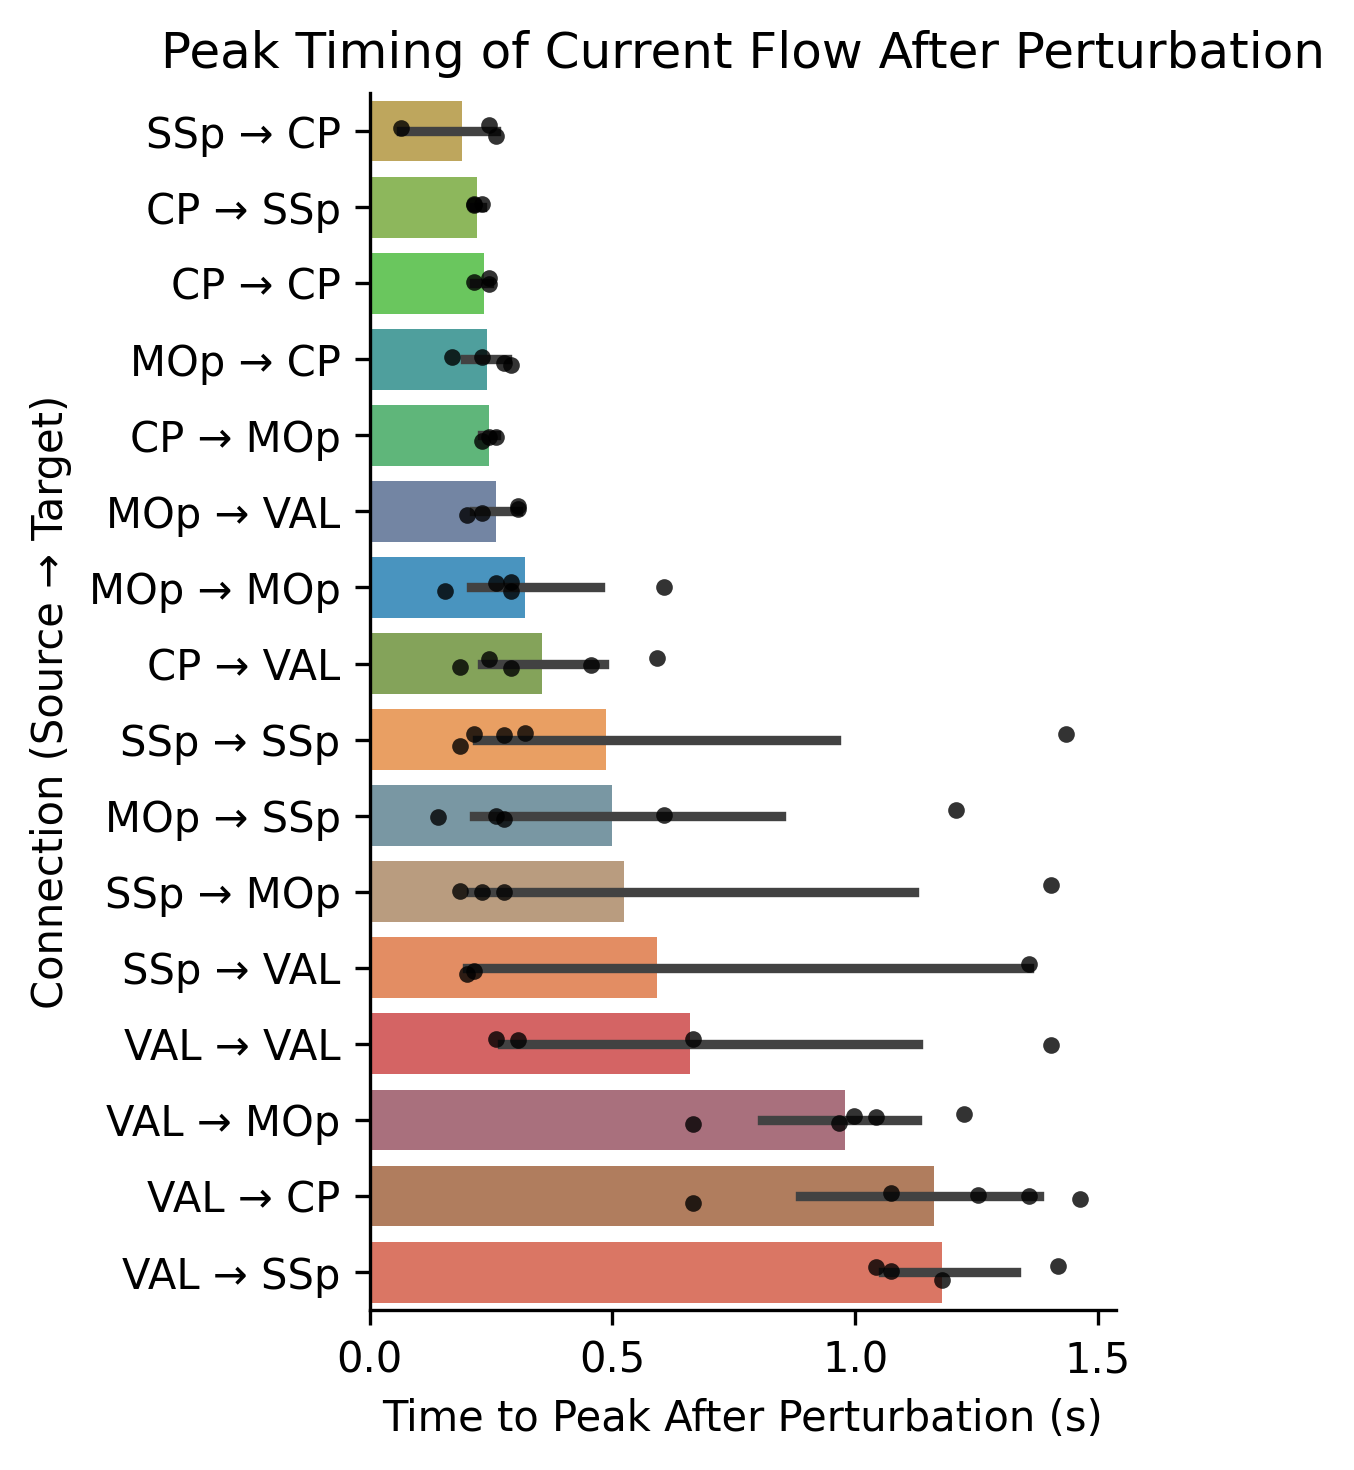

In [56]:
# Make sure connection labels match your color dict format
# Replace "→" with "to" for lookup
peak_timings_df["connection_key"] = peak_timings_df["connection"].str.replace("→", "to").str.strip()

# Order connections by mean peak timing
ordered_connections = (
    peak_timings_df.groupby("connection")["peak_time_after_perturb"]
    .mean()
    .sort_values()
    .index
)

# Build color list matching the order
bar_colors = [
    curbd_colors.get(conn.replace("→", "to").strip(), "gray")
    for conn in ordered_connections
]

# Set plot size
plt.figure(figsize=(4, 5), dpi=300)

# Barplot with custom palette + sorted order
sns.barplot(
    data=peak_timings_df,
    y="connection",
    x="peak_time_after_perturb",
    order=ordered_connections,
    errorbar=('ci', 95),
    palette=bar_colors
)

# Overlay data points (use same ordering and per-connection colors if desired)
sns.stripplot(
    data=peak_timings_df,
    y="connection",
    x="peak_time_after_perturb",
    order=ordered_connections,
    color="black",   # each strip matches its bar color
    size=4,
    jitter=True,
    alpha=0.8
)

# Formatting
plt.xlabel("Time to Peak After Perturbation (s)")
plt.ylabel("Connection (Source → Target)")
plt.title("Peak Timing of Current Flow After Perturbation")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()